<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
</head>
<body>
    <div style="display: flex; align-items: center;">
        <div>
            <h1>TD 1 - The Bandit Task</h1>
            <h2>Understanding human behavior with cognitive models</h2>
            <h3>Master in Cognitive Science</h3>
            <h4>École Normale Supérieure - PSL</h4>
            <p> Valentin Wyart - Lecturer<br>
                Amric Trudel - Practical Sessions (TD)<br>
                <a href="mailto:amric.trudel@ens.psl.eu">amric.trudel@ens.psl.eu</a></p>
        </div>
        <div>
            <img src="images/logo_ens.png" style="height: 70px; margin-left: 10px;" />
        </div>
    </div>
</body>
</html>

### Objectives:
Through this series of exercises, you will:
1. Familiarize yourself with the two-armed (restless) bandit task
2. Understand how cognitive models can be used to:
    - Simulate behavior on a cognitive task
    - Generate a variety of behaviors depending on their parameter settings
3. Characterize human behavior with a cognitive model

### Library imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from rl_model import RLModel

In [2]:
%matplotlib inline

# 1. The Two-armed Restless Bandit Task

## Play it!

The best way to understand a task is to try it! You will now play the 2-armed restless bandit task and save your decision trajectory.  
To run the Bandit app, first make sure you have installed the `gradio` python package. This is a local app, so all the computations will be done on your computer and nothing will be sent out to the internet.  

📝 Run the app and play the task until the end:
1. Execute the cell below.
2. If the app doesn't show up, you can also click  or copy-paste the given URL in your browser.

In [3]:
%run bandit_app.py

Running on local URL:  http://127.0.0.1:7860

To create a public link, set `share=True` in `launch()`.


## Visualize the Bandit values
Now, let's plot the value of the two bandit arms over the trials to visualize the structure of the task.  
The bandit dataset contains data for 10 games (you played the first one). We have one sequence of 80 trials for each of the two arms. This is why, when you load the data, you will obtain a tensor of dimensions 10 x 2 x 80.

In [5]:
bandit_data = np.load('bandit_data.npy')
bandit_data.shape

(10, 2, 80)

📝 Complete the code below in order to plot the trajectories of the two arms on the game you played.  
For this you will need to use a very well-known library called `matplotlib`. Don't hesitate to ask for guidance if it's your first time using this library.

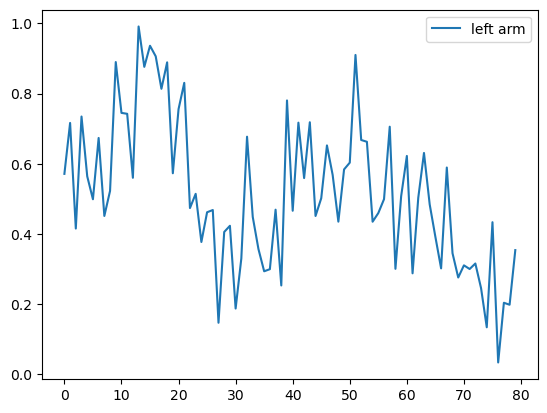

In [6]:
traj_no = 1

left_arm = bandit_data[traj_no, 0]
right_arm = bandit_data[traj_no, 1]

plt.plot(left_arm, label="left arm")
# Complete this code to:
#       1- Display the trajectory of the right arm on top of the other one
#       2- Add a title and x and y axis labels


######
plt.legend()
plt.show()

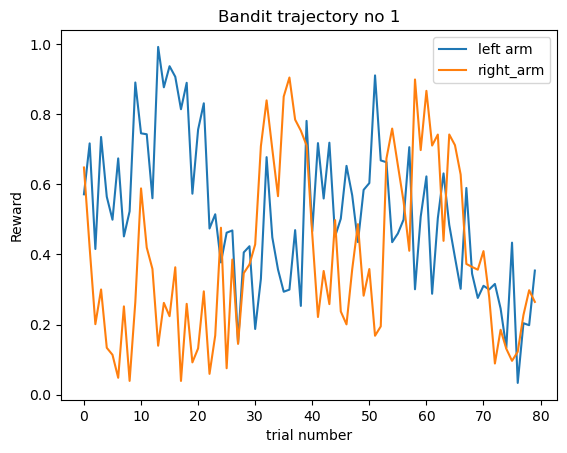

In [7]:
#Solution

plt.plot(left_arm, label="left arm")
#######
plt.plot(right_arm, label="right_arm")
plt.title(f"Bandit trajectory no {traj_no}")
plt.xlabel("trial number")
plt.ylabel("Reward")
######
plt.legend()
plt.show()

# Understanding how to use a cognitive model

## Simulate behavior with a model

We will simulate the behavior of a Reinforcement Learning model on this task. For now, there is no need to understand how it works internally, we will go back to it over the course of the semester. For now, you will get familiar with how we use it to generate behavior on the two-armed restless bandit task.

### A) Instantiate your first cognitive model and simulate behavior
The Reinforcement Learning model is implemented in `td1_rl_model.py` as a class. You can look at the code if you are curious, but all you need you do for now is to use it in this notebook. The code has been done with an object-oriented approach. This means that the script contains a **class** named `RLModel` that can be imported, instantiated, and used in this notebook. If you are not familiar with **object-oriented programming**, please ask for guidance. It will considerably help you understand how Python libraries are used.

When you create an **instance** of `RLModel`, you need to call its constructor and give values for the following parameters:
- learning_rate ($\alpha$) $\in [0, 1]$
- temperature ($\tau$) $\in [0, 1]$

📝 Instantiate the `RLModel` class with **values of your choice** for the two parameters (learning rate and temperature)

In [8]:
rl_model = ... # Fill this in

In [9]:
# Solution
rl_model = RLModel(learning_rate=0.5, temperature=1)

📝 Now you will make your model "play" the bandit task. For that, you can call the `simulate()` method, and pass ONE bandit trajectory to it. The model class will return an array of actions (one for each of the 80 trials), and an array of probabilities (we will look at them later).

In [10]:
bandit_values = bandit_data[traj_no]
actions, probs = ..., ... # Call the simulate() method on your instantiated RL model

In [11]:
# Solution
actions, probs = rl_model.simulate(bandit_values)

📝 Inspect the `actions` array and check that its shape and content are what you expected.

In [12]:
# Your code here


In [13]:
# Solution
print(actions.shape)
actions

(80,)


array([0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1])

### B) Visualize your model's behavior

The code below is a **function** that takes in bandit values and your model's actions. It performs the same bandit value visualization as we did previously, but it also shows the action that the model chose at each trial.

In [14]:
def visualize_behavior(bandit_values, actions):
    plt.plot(bandit_values[0], label="left arm")
    plt.plot(bandit_values[1], label="right arm")
    plt.title(f"Model actions on Two-Armed Restless Bandit Task")
    plt.xlabel("trial number")
    plt.ylabel("Reward")
    plt.scatter(np.where(actions==0)[0], actions[actions == 0], label="Choose left")
    plt.scatter(np.where(actions==1)[0], actions[actions==1], label="Choose right")
    plt.legend()
    plt.show()

📝 Call the `visualize_behavior` function to see your model's actions.  
Note: you have to run the cell above before you can use the function that is declared in it.

In [15]:
# Your code here


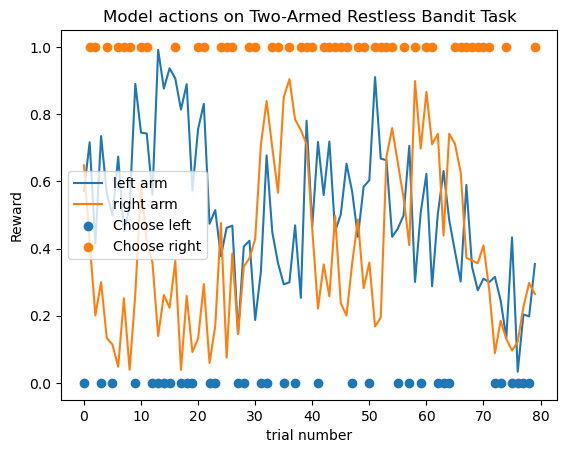

In [16]:
# Solution
visualize_behavior(bandit_values, actions)

Now, on top of the actions decided by the model, it would be nice to also see the evolution of the probability outputted by your model.
At each time step, the model generates a **probability of choosing the right arm**. The action is then sampled with a Bernoulli distribution.
$$p_t \leftarrow \text{model}$$
$$a_t \sim \text{Bernoulli}(p_t)$$

Where:
- $p_t \in [0, 1]$ is the probability of choosing the right arm
- $a_t \in \{0, 1\}$
    - a == 0 means choosing the left arm
    - a == 1 means choosing the right arm

Since each action $a_t$ is **sampled** from a probability distribution at each trial $t$, we are somehow losing some information about the internal state of the model if we only look at the actions. It would be also be interesting to see *to what extent* the model was likely to choose the action.

📝 Now, modify the visualize_behavior function to add the probability of choosing the right arm to the graph. For this you need to:
- Add an extra argument to the function, to take in the probabilities
- Add a line to plot the probabilities as a separate curve
- Add a label so that the probabilites are mentioned in the legend

In [17]:
# Your code here


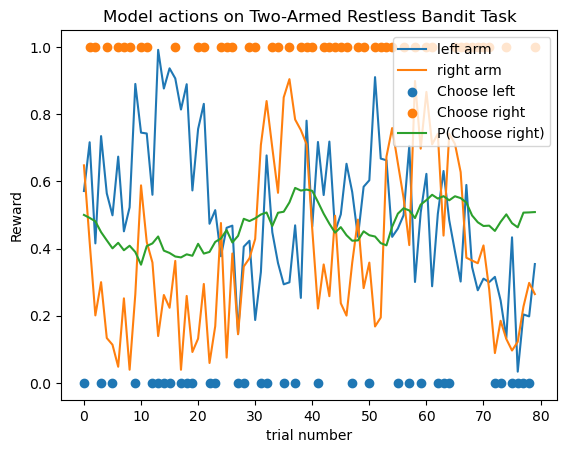

In [18]:
## Solution
def visualize_behavior_modified(bandit_values, actions, probabilities):
    plt.plot(bandit_values[0], label="left arm")
    plt.plot(bandit_values[1], label="right arm")
    plt.title(f"Model actions on Two-Armed Restless Bandit Task")
    plt.xlabel("trial number")
    plt.ylabel("Reward")
    plt.scatter(np.where(actions==0)[0], actions[actions == 0], label="Choose left")
    plt.scatter(np.where(actions==1)[0], actions[actions==1], label="Choose right")
    plt.plot(probabilities, label="P(Choose right)")
    plt.legend()
    plt.show()

visualize_behavior_modified(bandit_values, actions, probs)

### C) Test the impact of the parameters on the model
The parameter values you choose for your `RLModel` matter. It will change your model processes the rewards obtained in the task. You will simulate and visualize behavior with different parameter values and see for yourself what it changes. We haven't studied them so far, but you can try to vary the parameters one at a time and try to guess what they do.

📝 Instantiate an RLModel with a new set of values for `learning_rate` and `temperature`. Then visualize the actions as you did in the section above.  
    *Hint*: No need to copy the matplolib code again. You just need to call the function. This part of the exercise should fit in 4 lines of code maximum (you should use just only one cell)

In [19]:
# Your code here


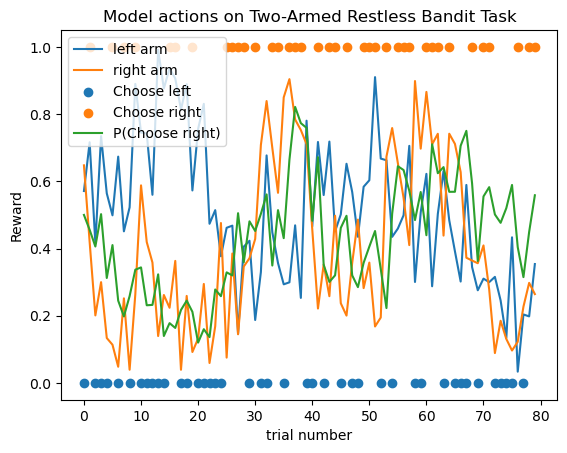

In [20]:
# Solution
rl_model = RLModel(1, 0.4)
actions, probs = rl_model.simulate(bandit_values)
visualize_behavior_modified(bandit_values, actions, probs)

## Fit a model to human data
Now it's time to see how to use the model with real human data. But which data will you use? YOURS!!  
Remember you tried the bandit task at the beginning of the exercise? Now it's time to fit a Reinforcement Learning model on it find to out what parameter values best correspond to your behavior!

📝 Now load your behavior data with `np.load()`. They are saved in two files:
- my_actions.npy
- my_rewards.npy
Load the two NumPy arrays and find out what shape they have to see how to use them with your model.

In [21]:
# Your code here


In [22]:
# Solution
my_actions = np.load('my_actions.npy')
my_rewards = np.load('my_rewards.npy')
my_actions.shape, my_rewards.shape

((80,), (80,))

Now, we will not instantiate the class by calling its contructor with parameters values because **the point is to find out what parameter values are most appropriate**. Instead, we will call the classmethod `RLModel.fit(actions, rewards)`. This method will run an **optimization routine** to find out what parameter set maximizes the likelihood of the model generating your actions given the rewards you got. At the end, the method automatically returns an instance of `RLModel` with the optimal parameters.  
📝 Call the `fit()` method to fit an RLModel to your data.  

In [23]:
# Your code here


In [24]:
# Solution
my_model = RLModel.fit(my_actions, my_rewards)

Beginning optimization of a DETERMINISTIC objective function

 Iteration    f-count         f(x)           MeshScale          Method             Actions
     0           2         69.5162               1                                 Uncertainty test
     0           6         54.6817               1         Initial mesh            Initial points
     0          10         53.7694             0.5         Refine grid             Train
     1          11         48.9667             0.5     Successful search (ES-wcm)        
     1          20         43.6075               1       Successful poll           Train
     2          26         43.6075             0.5         Refine grid             Train
     3          32         43.6075            0.25         Refine grid             Train
     4          35         41.7196            0.25     Successful search (ES-ell)        
     4          36         41.6707            0.25     Incremental search (ES-wcm)        
     4          38    

📝 Access the `learning_rate` and `temperature` **attributes** of your fitted model to find out what parameter values have been found to best characterize your behavior.

In [25]:
# Your code here


In [26]:
# Solution
print(f"learning rate: {my_model.learning_rate:.3f}")
print(f"temperature: {my_model.temperature:.3f}")

learning rate: 0.006
temperature: 0.000
